# Torch basics

In [3]:
import torch
import numpy as np

## Tensors

In [18]:
# Create tensor from data arrat
data = [[1, 2],[3, 4]]
x_tensor = torch.tensor(data)
print(f"Create torch tensor from array: {x_tensor}")

# Create tensor from numpy array
np_data = np.array(data)
x_tensor_from_numpy = torch.from_numpy(np_data)
# or 
x_tensor2 = torch.Tensor(np_data)
print(f"Create tensor from np array: {x_tensor_from_numpy}")


# Inherit from another tensor
x_one = torch.ones_like(x_tensor)
print(f"Create one tensor from other tensor with same shape:\n{x_one}\n")
x_rand = torch.rand_like(x_tensor, dtype=float)
print(f"Create one tensor from other tensor with same shape:\n{x_rand}\n")

Create torch tensor from array: tensor([[1, 2],
        [3, 4]])
Create tensor from np array: tensor([[1, 2],
        [3, 4]])
Create one tensor from other tensor with same shape:
tensor([[1, 1],
        [1, 1]])

Create one tensor from other tensor with same shape:
tensor([[0.7414, 0.4604],
        [0.4980, 0.7462]], dtype=torch.float64)



| Type | PyTorch Alias | Bit Depth | Common Use Case |
|---|---|---|---|
| Float | `torch.float32` | 32-bit | Model weights, gradients, image pixels (0-1). |
| Long | `torch.int64` | 64-bit | Class labels, indices for slicing, word IDs. |
| Int | `torch.int32` | 32-bit | General integer math, less common for indexing. |
| Double | `torch.float64` | 64-bit | High-precision physics simulations. |
| Byte | `torch.uint8` | 8-bit | Boolean masks (older versions) or raw pixel data (0-255). |

### Attributes of a Tensor

In [20]:
tensor = torch.rand(3,4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


### Manipulating the tensors

#### Indexing

In [24]:
tensor = torch.ones(4, 4)
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[:, -1]}") # or {tensor[..., -1]}
tensor[:,1] = 0
print(tensor)

First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


#### Concatenate the tensor !!! Important

In [38]:
# Joint append the tensor along denoted dimension.
# for e.g. For tensor 1 (m, n) and tensor 2 (m, h), cat will leading to (m, n+h)
t1 = torch.cat([tensor, tensor, tensor], dim=1)
print(t1)

tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])


#### Reshape the tensor !!!!! important

<u>torch.unsqueeze</u>

In [ ]:
t_reshaped = tensor.view

#### Arithmetic operations

In [46]:
# Multiplication
y1 = torch.matmul(tensor, tensor)
print(y1)
# or mul by @, here T means the transpose
y2 = tensor@tensor.T
print(y2)

# This computes the element-wise product. z1, z2, z3 will have the same value
z1 = tensor * tensor
z2 = tensor.mul(tensor)

z3 = torch.rand_like(tensor)
torch.mul(tensor, tensor, out=z3)

tensor([[3., 0., 3., 3.],
        [3., 0., 3., 3.],
        [3., 0., 3., 3.],
        [3., 0., 3., 3.]])
tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])


tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

Single-element tensors If you have a one-element tensor, for example by aggregating all values of a tensor into one value, you can convert it to a Python numerical value using item():

In [47]:
agg = tensor.sum()
agg_item = agg.item()
print(agg_item, type(agg_item))

12.0 <class 'float'>


In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [6]:
help(np.linspace)

Help on _ArrayFunctionDispatcher in module numpy:

linspace(start, stop, num=50, endpoint=True, retstep=False, dtype=None, axis=0)
    Return evenly spaced numbers over a specified interval.

    Returns `num` evenly spaced samples, calculated over the
    interval [`start`, `stop`].

    The endpoint of the interval can optionally be excluded.

    .. versionchanged:: 1.16.0
        Non-scalar `start` and `stop` are now supported.

    .. versionchanged:: 1.20.0
        Values are rounded towards ``-inf`` instead of ``0`` when an
        integer ``dtype`` is specified. The old behavior can
        still be obtained with ``np.linspace(start, stop, num).astype(int)``

    Parameters
    ----------
    start : array_like
        The starting value of the sequence.
    stop : array_like
        The end value of the sequence, unless `endpoint` is set to False.
        In that case, the sequence consists of all but the last of ``num + 1``
        evenly spaced samples, so that `stop` is exc

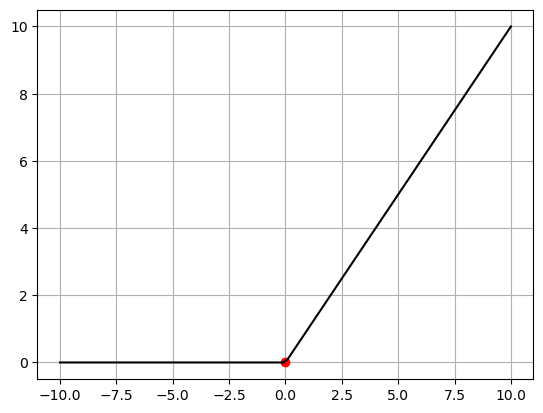

In [27]:
x = np.linspace(-10, 10, 100)
def sigmoid(x):
    y = 1/(1+np.exp(-x))
    return y

def softplus(x, beta: float, threshold: int):
    y = 1/beta * np.log(1 + np.exp(beta*x))
    return y

def relu(x):
    y = (np.abs(x)+x)/2
    return y
    
plt.grid()
plt.plot(0, relu(0), marker='o', color = 'red',linestyle='') 
plt.plot(x, relu(x), color = 'black' )
plt.show()
